In [ ]:
pip install -r requirements.txt

# Import required libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load dataset

In [3]:

data = pd.read_csv("../data/creditcard.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Check fraud vs normal transactions

In [4]:

fraud_counts = data['Class'].value_counts()

print(fraud_counts)
print("\nFraud percentage:", fraud_counts[1] / len(data) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727485630620034


# Visualize Transaction Amounts

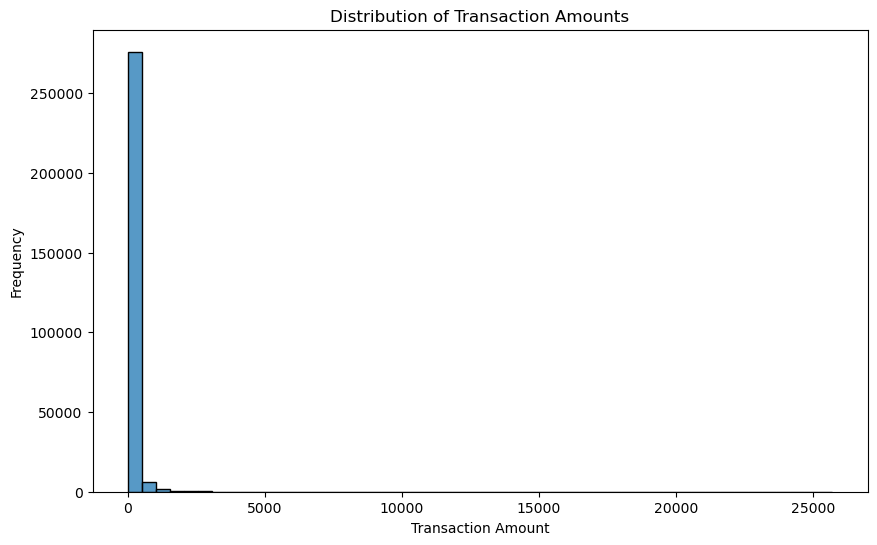

In [5]:

plt.figure(figsize=(10,6))

sns.histplot(data["Amount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

# Separate features and labels

In [6]:

X = data.drop("Class", axis=1)
y = data["Class"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (284807, 30)


# Train anomaly detection model

In [7]:

model = IsolationForest(
    n_estimators=100,
    contamination=0.001,
    random_state=42
)

model.fit(X)

print("Model training complete.")

Model training complete.


# Predict anomalies

In [8]:

predictions = model.predict(X)

# Convert output
predictions = [1 if x == -1 else 0 for x in predictions]

print("Predictions generated.")

Predictions generated.


# We Evaluate the Model

In [9]:

from sklearn.metrics import classification_report

print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.17      0.21       492

    accuracy                           1.00    284807
   macro avg       0.64      0.58      0.61    284807
weighted avg       1.00      1.00      1.00    284807



Here, you will see precision, recall, and F1-score.

Remember: anomaly detection is not perfect fraud detection. It flags suspicious patterns, which humans or other systems investigate further.

# Next step — We Will then Visualize Detected Anomalies

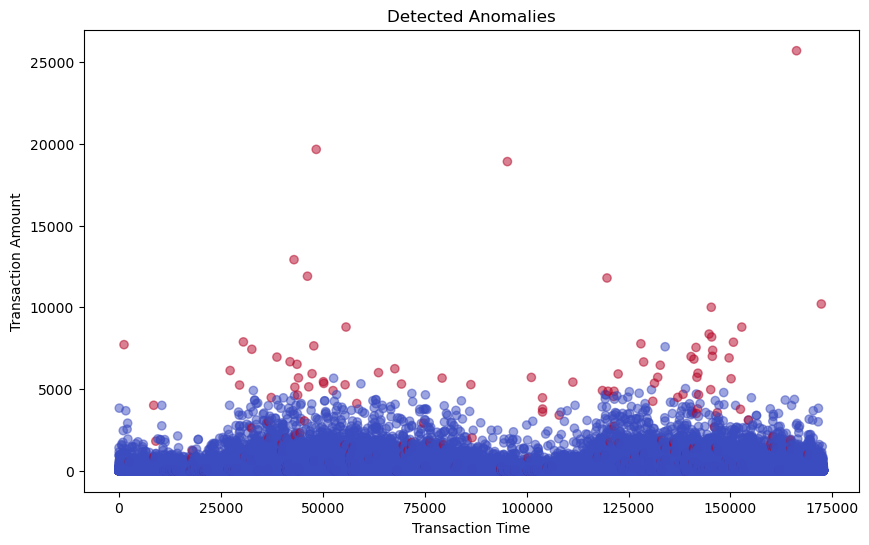

In [10]:

plt.figure(figsize=(10,6))

plt.scatter(
    data["Time"],
    data["Amount"],
    c=predictions,
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("Transaction Time")
plt.ylabel("Transaction Amount")
plt.title("Detected Anomalies")

plt.show()